In [27]:
import numpy as np
import matplotlib.pyplot as plt

# One useless weight: input x and target y are independent standard normals, so the best
# weight is exactly 0.
#   plain LMS:   w <- w - alpha * (w*x - y) * x
#   with L1:     w <- w - alpha * ((w*x - y) * x + lam * sign(w))
N_STEPS = 200_000
STEP_SIZES = 10.0 ** -np.arange(1, 9)        # 1e-1, 1e-2, ..., 1e-8
LAM = 0.001

rng = np.random.default_rng(0)
x = rng.standard_normal(N_STEPS)
y = rng.standard_normal(N_STEPS)

def simulate(lam):
    """Every step-size sees the same data stream, so nothing but alpha differs."""
    w = np.zeros(len(STEP_SIZES))
    history = np.empty((N_STEPS, len(STEP_SIZES)))
    for t in range(N_STEPS):
        w -= STEP_SIZES * ((w * x[t] - y[t]) * x[t] + lam * np.sign(w))
        history[t] = w
    return history

def plot(history, title):
    fig, axes = plt.subplots(4, 2, figsize=(13, 13))
    for ax, a, w_hist in zip(axes.ravel(), STEP_SIZES, history.T):
        ax.plot(w_hist, lw=0.4)
        ax.axhline(0, color='k', lw=0.8)
        ax.set_title(f'$\\alpha$ = {a:.0e}')
        ax.set_xlabel('step')
        ax.set_ylabel('$w$')
    fig.suptitle(title, fontsize=13)
    fig.tight_layout()
    plt.show()

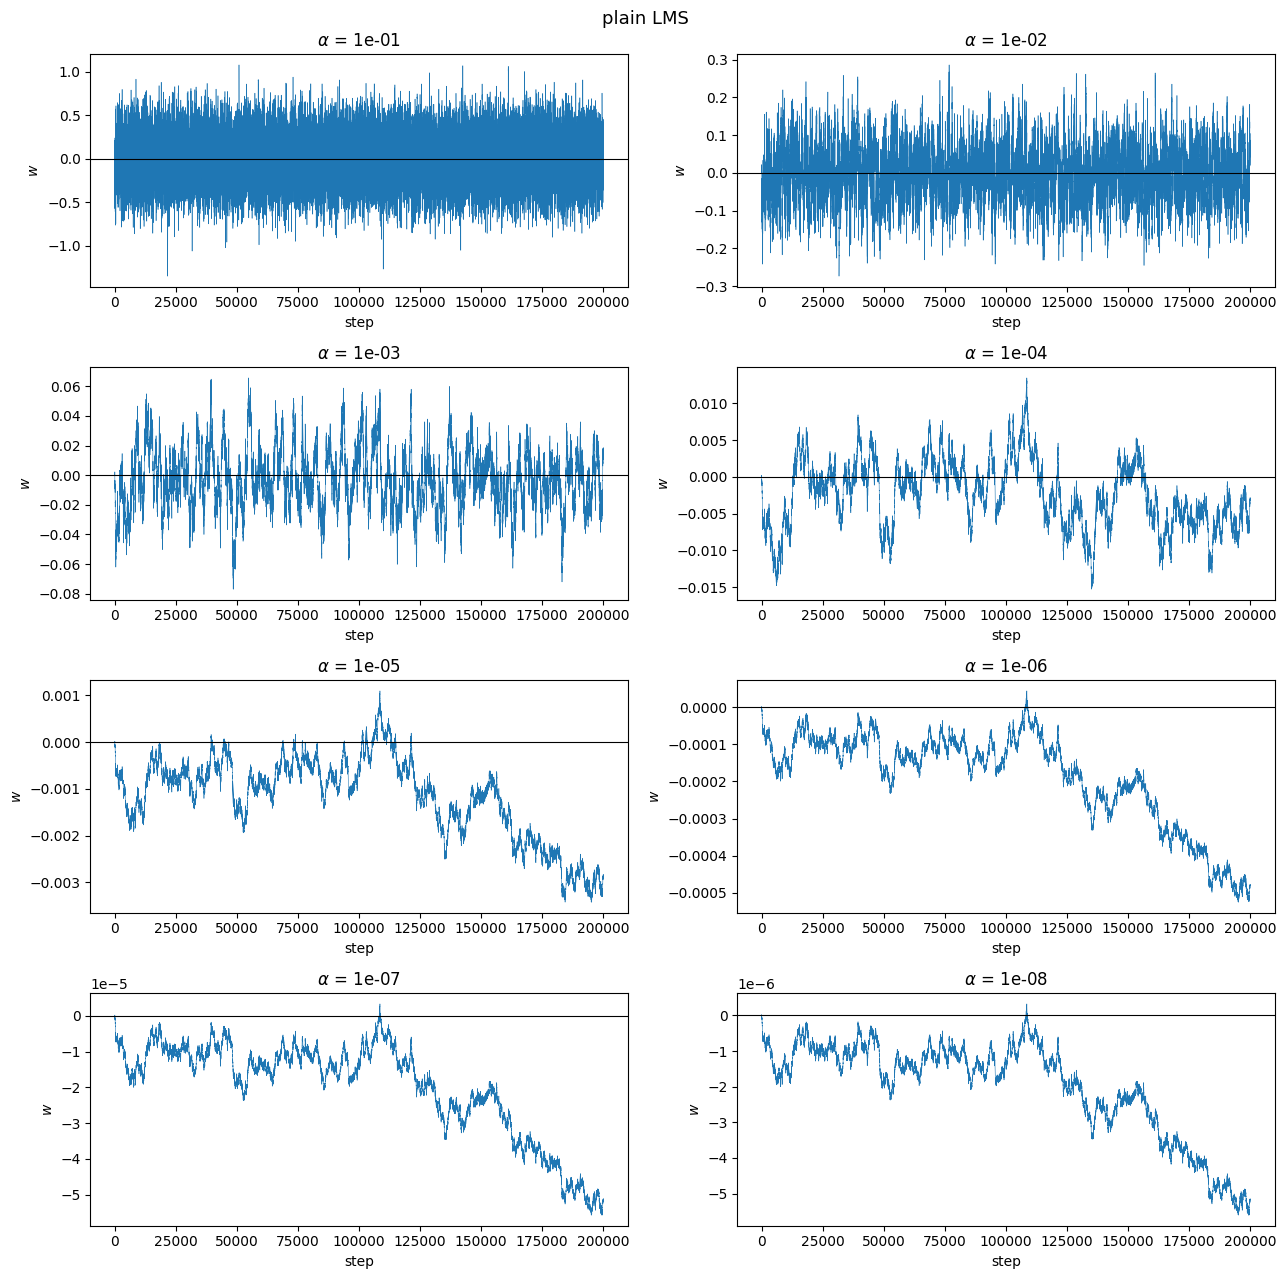

In [28]:
# The pull is alpha*w, so its RATE is alpha: it needs 1/alpha steps to act. The bottom panels
# never get there and just wander.
plot(simulate(0.0), 'plain LMS')

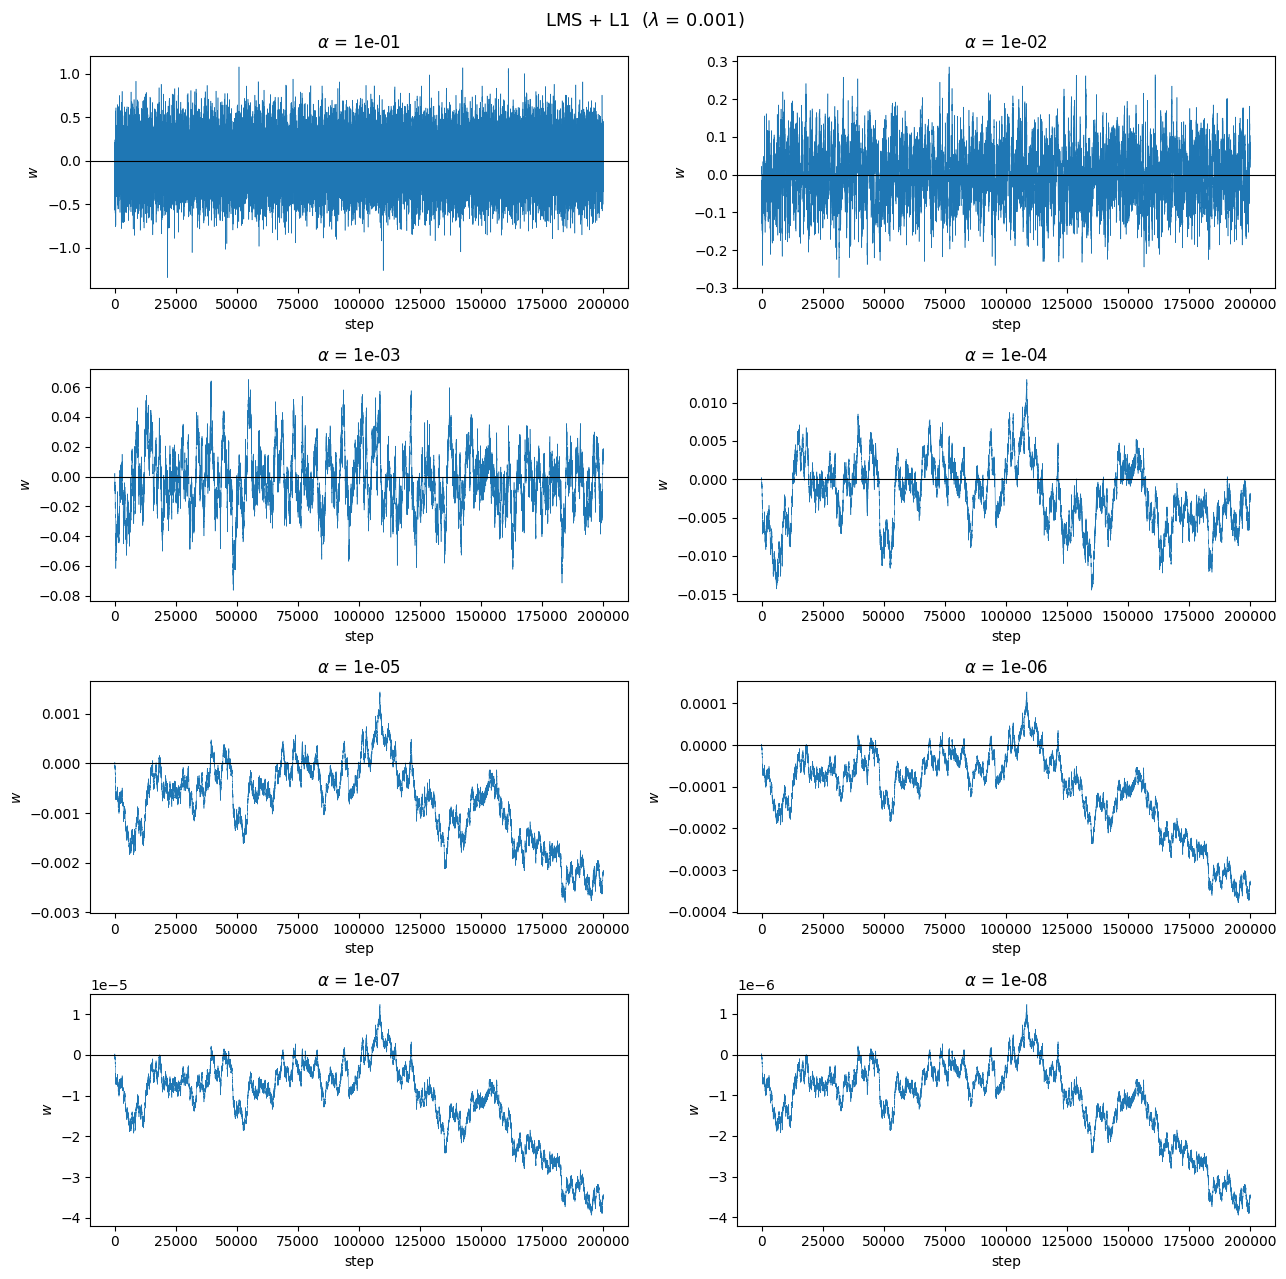

In [29]:
# The L1 pull is alpha*lam, a fixed size that does not shrink as w approaches 0, so it is a
# VELOCITY rather than a rate and carries no 1/alpha timescale. Every panel now settles and
# crosses zero at the same period, differing only in amplitude.
plot(simulate(LAM), f'LMS + L1  ($\\lambda$ = {LAM})')